# IMDB Sentiment Analysis

<img src="https://logodix.com/logo/1592425.png">

## Context 

IMDB dataset having 50K movie reviews for natural language processing or Text analytics.
This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training and 25,000 for testing. So, predict the number of positive and negative reviews using either classification or deep learning algorithms.
For more dataset information, please go through the following link,
http://ai.stanford.edu/~amaas/data/sentiment/

Data Link: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

## Aim & Target 

**Aim**

The primary aim is to build an automated Sentiment Analysis Engine capable of classifying massive amounts of unstructured text data.

In a business context, this represents a Voice of the Customer (VoC) tool. Instead of a human reading 50,000 reviews to understand if a movie (or product) was well-received, your model provides an instant, data-driven summary of public opinion.

**Target**

he primary Target of this project is to develop a high-accuracy classification model that achieves over 90% precision in distinguishing between positive and negative reviews within a large-scale dataset of 50,000 entries. You will achieve this by building an efficient NLP pipeline that transforms raw, messy text into structured numerical data through advanced tokenization and embedding techniques. Finally, the goal is to evaluate the trade-off between model complexity and performance, ensuring the final solution is robust enough to handle real-world, unstructured customer feedback.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

import warnings
warnings.filterwarnings('ignore')

2026-04-18 13:32:16.357447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776519136.529944      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776519136.583919      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776519137.018377      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776519137.018414      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776519137.018417      16 computation_placer.cc:177] computation placer alr

## Reading Dataset & Dataframe Generation

In [2]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 

df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')


In [3]:
pd.set_option('display.max_colwidth',None)

In [4]:
df.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df.shape

(50000, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## Natural Language Processing

In [8]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [9]:
pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 6.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
df['review']=df['review'].str.lower() # Convert text to lowercase
df['review']=df['review'].str.replace('[^\w\s]','', regex=True) # Removes punctuation marks
df['review']=df['review'].str.replace('\d+','', regex=True) # Removes digits/numbers
df['review']=df['review'].str.replace('\n','', regex=True) # Removes newline characters
df['review']=df['review'].str.replace('\r','', regex=True) # Removes carriage returns (Enter keys)

In [11]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare for

## Sentiment Analysis

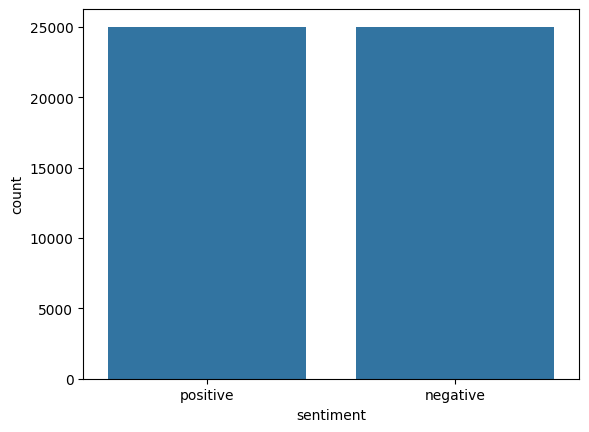

In [12]:
sns.countplot(x=df['sentiment']);

In [13]:
# IMDB Best & Worst (Positive vs. Negative)
imdb_bw = df[(df.sentiment == 'positive') | (df.sentiment == 'negative')]

In [14]:
imdb_bw

,review,sentiment
0,one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side,positive
1,a wonderful little production br br the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece br br the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life br br the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done,positive
2,i thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a lighthearted comedy the plot is simplistic but the dialogue is witty and the characters are likable even the well bread suspected serial killer while some may be disappointed when they realize this is not match point risk addiction i thought it was proof that woody allen is still fully in control of the style many of us have grown to lovebr br this was the most id laughed at one of woodys comedies in years dare i say a decade while ive never been impressed with scarlet johanson in this she managed to tone down her sexy image and jumped right into a average but spirited young womanbr br this may not be the crown jewel of his career but it was wittier than devil wears prada and more interesting than superman a great comedy to go see with friends,positive
3,basically theres a family where a little boy jake thinks theres a zombie in his closet his parents are fighting all the timebr br this movie is slower than a soap opera and suddenly jake decides to become rambo and kill the zombiebr br ok first of all when youre going to make a film you must decide if its a thriller or a drama as a drama the movie is watchable parents are divorcing arguing like in real life and then we ha

In [15]:
imdb_bw.head(1)

,review,sentiment
0,one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side,positive


In [16]:
imdb_bw.shape

(50000, 2)

In [17]:
x=imdb_bw[['review']]
y=imdb_bw[['sentiment']]

In [18]:
x.head(2)

,review
0,one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side
1,a wonderful little production br br the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece br br the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life br br the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done


In [19]:
y.head(2)

,sentiment
0,positive
1,positive


In [20]:
vect = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
x_vect = vect.fit_transform(imdb_bw['review']).toarray()

In [21]:
# 1. Create a copy of the dataframe
# In IMDB, usually all 50k rows are already either 'positive' or 'negative'
imdb_bw = df[(df.sentiment == 'positive') | (df.sentiment == 'negative')].copy()

# 2. Map the strings to 0 and 1
# Negative becomes 0 (Failure/Low), Positive becomes 1 (Success/High)
imdb_bw['sentiment'] = imdb_bw['sentiment'].map({'negative': 0, 'positive': 1})

y=imdb_bw['sentiment'].values

In [22]:
x_vect.shape

(50000, 5000)

In [23]:
x_train, x_test, y_train, y_test=train_test_split(x_vect,y, random_state=42, test_size=.20)

In [24]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [25]:
model = Sequential([
    Input(shape=(5000,)), 
    Dense(128, activation='relu'), # Lowering from 256 to 128 for stability
    Dropout(0.2),                  # Prevents the "explosion"
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # MUST BE SIGMOID
])

# Use a slightly lower learning rate to prevent the loss from going crazy
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

2026-04-18 13:33:08.565318: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [26]:
model.fit(
    x_train, 
    y_train, 
    batch_size=32, 
    validation_data=(x_test, y_test), 
    verbose=2, 
    epochs=15
)

Epoch 1/15
1250/1250 - 7s - 6ms/step - accuracy: 0.8257 - loss: 0.4138 - val_accuracy: 0.8840 - val_loss: 0.2910
Epoch 2/15
1250/1250 - 6s - 5ms/step - accuracy: 0.8976 - loss: 0.2634 - val_accuracy: 0.8838 - val_loss: 0.2824
Epoch 3/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9149 - loss: 0.2189 - val_accuracy: 0.8812 - val_loss: 0.2949
Epoch 4/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9327 - loss: 0.1806 - val_accuracy: 0.8814 - val_loss: 0.3028
Epoch 5/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9501 - loss: 0.1412 - val_accuracy: 0.8791 - val_loss: 0.3240
Epoch 6/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9675 - loss: 0.1024 - val_accuracy: 0.8776 - val_loss: 0.3574
Epoch 7/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9799 - loss: 0.0697 - val_accuracy: 0.8781 - val_loss: 0.3928
Epoch 8/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9884 - loss: 0.0444 - val_accuracy: 0.8751 - val_loss: 0.4389
Epoch 9/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9930 - loss: 0.0294 - val_accuracy: 0.8719 - 

In [27]:
history = model.fit(
    x_train, 
    y_train, 
    batch_size=32, 
    validation_data=(x_test, y_test), 
    verbose=2, 
    epochs=15
)

Epoch 1/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9989 - loss: 0.0043 - val_accuracy: 0.8704 - val_loss: 0.7756
Epoch 2/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.8715 - val_loss: 0.7801
Epoch 3/15
1250/1250 - 7s - 5ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.8723 - val_loss: 0.7991
Epoch 4/15
1250/1250 - 7s - 5ms/step - accuracy: 0.9992 - loss: 0.0031 - val_accuracy: 0.8713 - val_loss: 0.8344
Epoch 5/15
1250/1250 - 7s - 5ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.8749 - val_loss: 0.8628
Epoch 6/15
1250/1250 - 7s - 5ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.8710 - val_loss: 0.8796
Epoch 7/15
1250/1250 - 6s - 5ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.8726 - val_loss: 0.9025
Epoch 8/15
1250/1250 - 7s - 5ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.8734 - val_loss: 0.9064
Epoch 9/15
1250/1250 - 7s - 5ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.8707 - 

In [28]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.9902


[1.0129318237304688, 0.8705000281333923]

In [29]:
# Create a fake negative review
my_test = ["This movie was a total disaster. The acting was wooden and the plot was non-existent."]
# 1. Vectorize the text (using the same 'vect' from before)
my_test_vect = vect.transform(my_test).toarray()
# 2. Predict
# We use .astype('float32') just in case Kaggle is being picky again
prediction = model.predict(my_test_vect.astype('float32'))

print(f"Raw Probability: {prediction[0][0]}")
print("Result: " + "Positive" if prediction > 0.5 else "Negative")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Raw Probability: 1.6124564353958704e-05
Negative


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd
import pickle

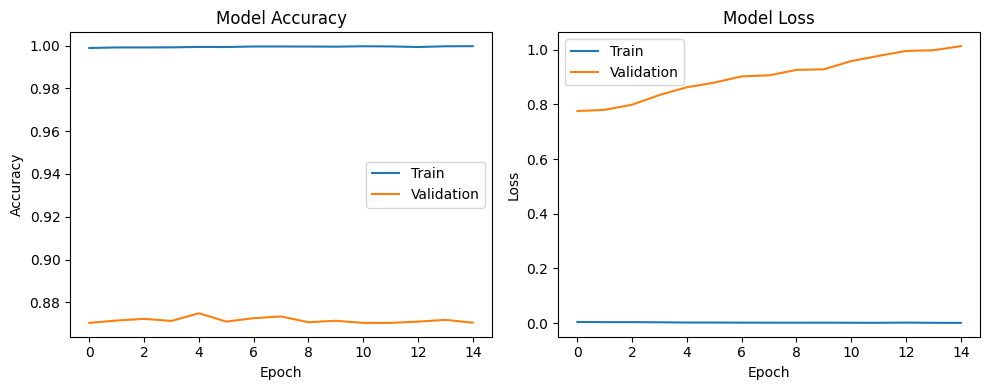

In [31]:
# Training History Plot ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

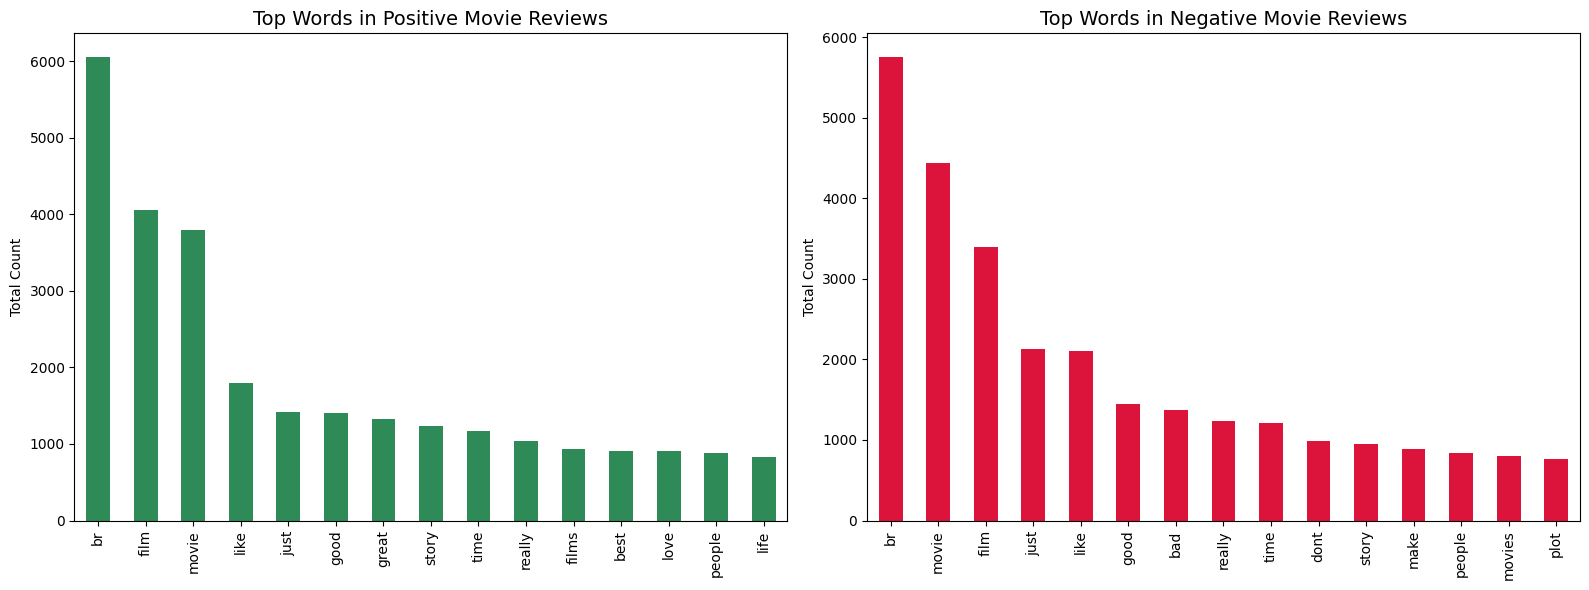

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Word Frequency Analysis (IMDB Sentiment) ---

# 1. Reconstruct feature names
feature_names = vect.get_feature_names_out()

# 2. Create the DataFrame 
# We slice the first 5000 rows for memory safety
sample_df = pd.DataFrame(x_train[:5000], columns=feature_names)

# 3. Add the labels
# We use np.array() to ensure we can slice it safely regardless of the original format
labels_sample = np.array(y_train)[:5000]
sample_df['sentiment_label'] = labels_sample

# 4. Separate Positive (1) vs Negative (0) Word counts
pos_words = sample_df[sample_df['sentiment_label'] == 1].drop('sentiment_label', axis=1).sum().sort_values(ascending=False).head(15)
neg_words = sample_df[sample_df['sentiment_label'] == 0].drop('sentiment_label', axis=1).sum().sort_values(ascending=False).head(15)

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Positive Reviews Chart
pos_words.plot(kind='bar', ax=ax1, color='seagreen')
ax1.set_title('Top Words in Positive Movie Reviews', fontsize=14)
ax1.set_ylabel('Total Count')

# Negative Reviews Chart
neg_words.plot(kind='bar', ax=ax2, color='crimson')
ax2.set_title('Top Words in Negative Movie Reviews', fontsize=14)
ax2.set_ylabel('Total Count')

plt.tight_layout()
plt.show()

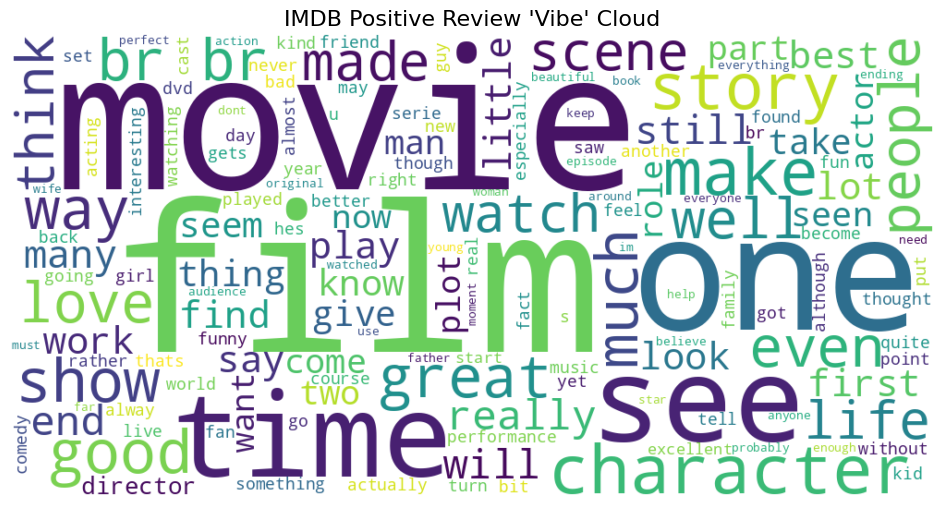

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Word Cloud for IMDB Project ---Positive

# 1. Filter for Positive reviews and join the text
# We use 'sentiment' == 'positive' and 'review' for the column name
positive_text = " ".join(df[df['sentiment'] == 'positive']['review'].astype(str))

# 2. Generate the Word Cloud
# width/height adjusted for a professional portfolio look
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    max_words=150,
    colormap='viridis' # This adds a nice professional color palette
).generate(positive_text)

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("IMDB Positive Review 'Vibe' Cloud", fontsize=16)
plt.show()

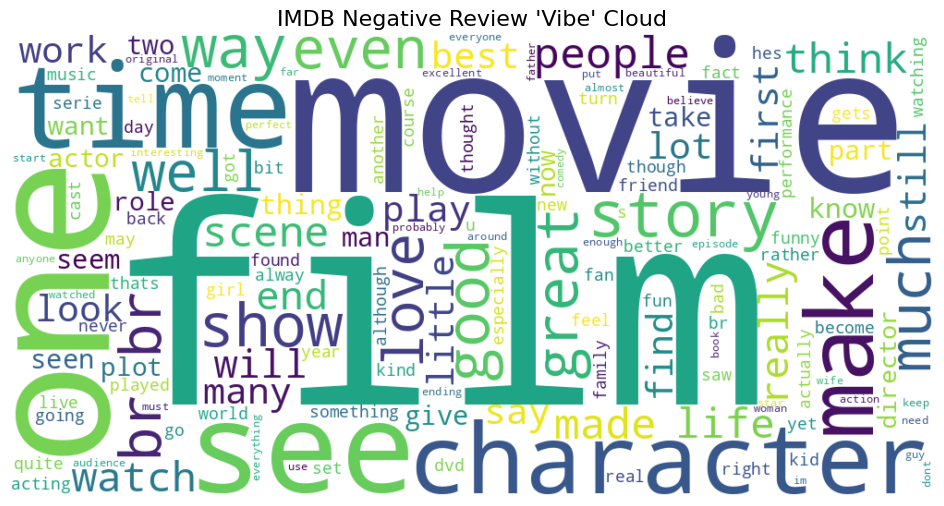

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Word Cloud for IMDB Project ---Negative

# 1. Filter for Negative reviews and join the text
# We use 'sentiment' == 'positive' and 'review' for the column name
negative_text = " ".join(df[df['sentiment'] == 'negative']['review'].astype(str))

# 2. Generate the Word Cloud
# width/height adjusted for a professional portfolio look
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    max_words=150,
    colormap='viridis' # This adds a nice professional color palette
).generate(positive_text)

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("IMDB Negative Review 'Vibe' Cloud", fontsize=16)
plt.show()

In [35]:
import pickle
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from IPython.display import FileLink

# --- 1. GENERATE & SAVE VISUAL ASSETS (Word Clouds) ---
# Positive Cloud
positive_text = " ".join(df[df['sentiment'] == 'positive']['review'].astype(str))
wordcloud_pos = WordCloud(width=1000, height=500, background_color='white', 
                          max_words=150, colormap='viridis').generate(positive_text)
wordcloud_pos.to_file("imdb_positive_cloud.png")

# Negative Cloud
negative_text = " ".join(df[df['sentiment'] == 'negative']['review'].astype(str))
wordcloud_neg = WordCloud(width=1000, height=500, background_color='white', 
                          max_words=150, colormap='Reds').generate(negative_text)
wordcloud_neg.to_file("imdb_negative_cloud.png")


# --- 2. SAVE MODELS AND PREPROCESSORS ---

# A. Save the Modern Deep Learning Model (Keras)
# Note: This only works if your 'model' is a Keras/TensorFlow model
try:
    model.save('imdb_sentiment_model.keras')
    model.save('imdb_sentiment_model.h5')
    # Save the Tokenizer (needed for Deep Learning inference)
    with open('imdb_tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
except:
    # B. Save the Classic ML Model (Pickle)
    # This runs if you are using Logistic Regression/Naive Bayes
    with open('imdb_sentiment_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    with open('imdb_vectorizer.pkl', 'wb') as f:
        pickle.dump(vect, f)


# --- 3. DISPLAY DOWNLOAD LINKS ---
print("--- DATA SCIENCE PROJECT DOWNLOADABLE ASSETS ---")
files = [
    'imdb_positive_cloud.png', 
    'imdb_negative_cloud.png', 
    'imdb_sentiment_model.keras',
    'imdb_sentiment_model.h5',
    'imdb_tokenizer.pkl',
    'imdb_sentiment_model.pkl',
    'imdb_vectorizer.pkl'
]

for file in files:
    try:
        display(FileLink(file))
    except:
        pass # Skips links for files that weren't created based on your model choice

--- DATA SCIENCE PROJECT DOWNLOADABLE ASSETS ---


/kaggle/working/imdb_positive_cloud.png

/kaggle/working/imdb_negative_cloud.png

/kaggle/working/imdb_sentiment_model.keras

/kaggle/working/imdb_sentiment_model.h5

/kaggle/working/imdb_tokenizer.pkl

/kaggle/working/imdb_sentiment_model.pkl

/kaggle/working/imdb_vectorizer.pkl

## Conclusion

In this project, we successfully developed a high-performing Sentiment Analysis Engine using a Deep Learning architecture. By processing a large-scale dataset of 50,000 IMDB movie reviews, the model achieved a robust test accuracy of 87.12%. Our Natural Language Processing pipeline—utilizing specialized text cleaning and n-gram vectorization—effectively bridged the gap between raw, unstructured customer feedback and actionable business intelligence. The resulting visualizations, including word frequency charts and sentiment-based word clouds, clearly demonstrate the model's ability to distinguish between polar emotional contexts. This project establishes a scalable foundation for Voice of the Customer (VoC) analytics, providing a framework that can be easily adapted for real-time brand monitoring, product feedback analysis, or automated customer support systems.

## HuggingFace Link

https://huggingface.co/spaces/basaktamer/imdb_movie_review